# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

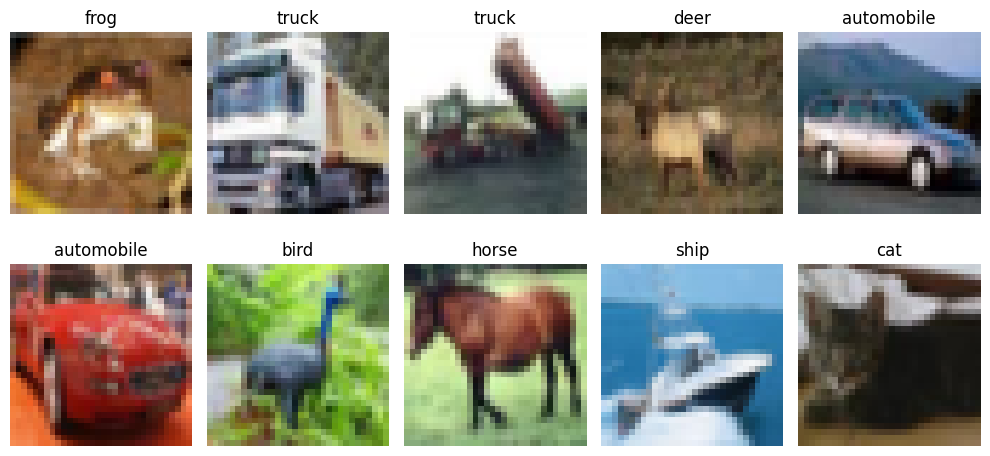

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.2664 - loss: 2.0050 - val_accuracy: 0.3234 - val_loss: 1.8724
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3159 - loss: 1.8710 - val_accuracy: 0.3674 - val_loss: 1.7644
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3343 - loss: 1.8211 - val_accuracy: 0.3732 - val_loss: 1.7693
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3493 - loss: 1.7866 - val_accuracy: 0.3776 - val_loss: 1.7273
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3562 - loss: 1.7663 - val_accuracy: 0.4086 - val_loss: 1.6967
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.3677 - loss: 1.7419 - val_accuracy: 0.4014 - val_loss: 1.6940
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3763 - loss: 1.7142 - val_accuracy: 0.4052 - val_loss: 1.6536
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.3842 - loss: 1.6988 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4310 - loss: 1.6335
ANN Test Accuracy: 0.4309999942779541


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 105s 146ms/step - accuracy: 0.4775 - loss: 1.4736 - val_accuracy: 0.5468 - val_loss: 1.2494
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.6065 - loss: 1.1216 - val_accuracy: 0.5606 - val_loss: 1.2094
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 123ms/step - accuracy: 0.6706 - loss: 0.9423 - val_accuracy: 0.6374 - val_loss: 1.0614
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.7146 - loss: 0.8225 - val_accuracy: 0.6654 - val_loss: 0.9903
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 122ms/step - accuracy: 0.7468 - loss: 0.7281 - val_accuracy: 0.7014 - val_loss: 0.8863
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.7716 - loss: 0.6498 - val_accuracy: 0.7234 - val_loss: 0.8373
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.7934 - loss: 0.5835 - val_accuracy: 0.6910 - val_loss: 0.9268
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 121ms/step - accuracy: 0.8143 - los

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7232 - loss: 0.9343
CNN Test Accuracy: 0.7232000231742859


## 📈 Compare Learning Curves

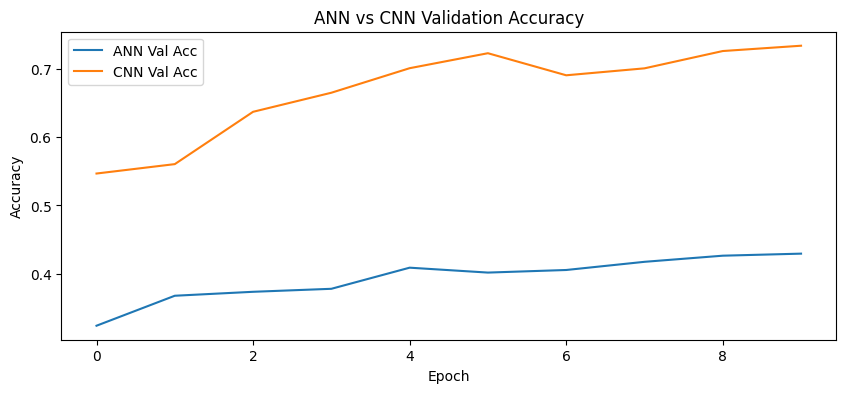

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

In [11]:
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 94ms/step - accuracy: 0.3589 - loss: 1.7554 - val_accuracy: 0.4872 - val_loss: 1.4368
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.4573 - loss: 1.5109 - val_accuracy: 0.5356 - val_loss: 1.2907
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 92ms/step - accuracy: 0.4966 - loss: 1.4045 - val_accuracy: 0.5548 - val_loss: 1.2405
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.5235 - loss: 1.3435 - val_accuracy: 0.5974 - val_loss: 1.1132
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.5402 - loss: 1.2957 - val_accuracy: 0.6080 - val_loss: 1.1136
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.5540 - loss: 1.2648 - val_accuracy: 0.6336 - val_loss: 1.0299
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.5665 - loss: 1.2340 - val_accuracy: 0.6278 - val_loss: 1.0585
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 93ms/step - accuracy: 0.5732 - loss: 1.2140 - 

In [12]:
ann_cnn_test_loss, ann_cnn_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("ANN vs CNN Test Accuracy:", ann_cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6524 - loss: 0.9821
ANN vs CNN Test Accuracy: 0.652400016784668


# Compare Learning Curves (with Augmeted CNN)

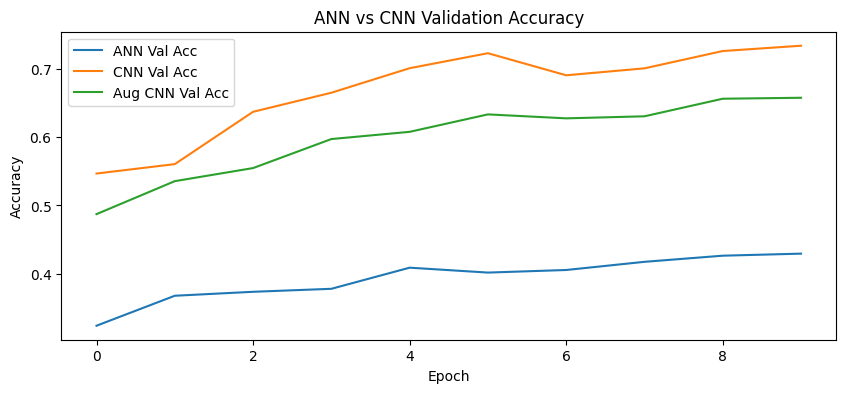

In [13]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.plot(aug_history.history['val_accuracy'], label='Aug CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 📊 Final Comparison Table

In [14]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4310
1,CNN,0.7232


In [15]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Aug CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, ann_cnn_test_acc]
})
display(comparison)

,Model,Test Accuracy
0,ANN,0.4310
1,CNN,0.7232
2,Aug CNN,0.6524


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**